In [ ]:
import os
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt

datasets_folder = "."  # current directory

# Build file paths
job_postings_path = os.path.join(datasets_folder, "job_postings.csv")
job_skills_path = os.path.join(datasets_folder, "job_skills.csv")
job_summary_path = os.path.join(datasets_folder, "job_summary.csv")

# Check that files exist
for f in [job_postings_path, job_skills_path, job_summary_path]:
    print("Exists:", os.path.exists(f), "→", f)

# Load datasets
postings = pd.read_csv(job_postings_path)
skills = pd.read_csv(job_skills_path)
summary = pd.read_csv(job_summary_path)

print("\n✅ All datasets loaded successfully!")
print("Job Postings shape:", postings.shape)
print("Job Skills shape:", skills.shape)
print("Job Summary shape:", summary.shape)


Exists: True → .\job_postings.csv
Exists: True → .\job_skills.csv
Exists: True → .\job_summary.csv

✅ All datasets loaded successfully!
Job Postings shape: (12217, 15)
Job Skills shape: (12217, 2)
Job Summary shape: (12217, 2)


In [15]:
# Merge datasets
df = postings.merge(skills, on="job_link", how="left").merge(summary, on="job_link", how="left")
df = df.drop_duplicates(subset="job_link")
# Quick check
print("Combined dataframe shape:", df.shape)
df.head(3)


Combined dataframe shape: (12217, 17)


,job_link,last_processed_time,last_status,got_summary,got_ner,is_being_worked,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type,job_skills,job_summary
0,https://www.linkedin.com/jobs/view/senior-mach...,2024-01-21 08:08:48.031964+00,Finished NER,t,t,f,Senior Machine Learning Engineer,Jobs for Humanity,"New Haven, CT",2024-01-14,East Haven,United States,Agricultural-Research Engineer,Mid senior,Onsite,"Machine Learning, Programming, Python, Scala, ...",Company Description\r\nJobs for Humanity is pa...
1,https://www.linkedin.com/jobs/view/principal-s...,2024-01-20 04:02:12.331406+00,Finished NER,t,t,f,"Principal Software Engineer, ML Accelerators",Aurora,"San Francisco, CA",2024-01-14,El Cerrito,United States,Set-Key Driver,Mid senior,Onsite,"C++, Python, PyTorch, TensorFlow, MXNet, CUDA,...",Who We Are\r\nAurora (Nasdaq: AUR) is deliveri...
2,https://www.linkedin.com/jobs/view/senior-etl-...,2024-01-21 08:08:31.941595+00,Finished NER,t,t,f,Senior ETL Data Warehouse Specialist,Adame Services LLC,"New York, NY",2024-01-14,Middletown,United States,Technical Support Specialist,Associate,Onsite,"ETL, Data Integration, Data Transformation, Da...","Location: New York City, NY\r\nPosition Summar..."


In [19]:
# -------------------------------
# Step 2: Filter only U.S. jobs
# -------------------------------
df_us = df[df['job_location'].str.contains("United States|US|USA", case=False, na=False)].copy()

# -------------------------------
# Step 3: Fill missing values
# -------------------------------
df_us['job_title'] = df_us['job_title'].fillna("")
df_us['job_skills'] = df_us['job_skills'].fillna("")
df_us['job_location'] = df_us['job_location'].fillna("")
df_us['job_type'] = df_us['job_type'].fillna("")
df_us['job_summary'] = df_us['job_summary'].fillna("")

# -------------------------------
# Step 4: Extract state from job_location
# -------------------------------
def extract_state(location):
    if not location:
        return None
    parts = re.split(r',\s*', location)
    if len(parts) >= 2:
        return parts[-1].strip()
    return None

df_us['state'] = df_us['job_location'].apply(extract_state)


In [20]:
# -------------------------------
# Step 5: Normalize work mode
# -------------------------------
def normalize_remote(x):
    x = str(x).lower()
    if any(tok in x for tok in ['remote only', 'fully remote', 'remote']):
        return 'remote'
    elif 'hybrid' in x:
        return 'hybrid'
    elif any(tok in x for tok in ['onsite', 'on-site', 'in office', 'office']):
        return 'onsite'
    else:
        return 'unspecified'

df_us['work_mode'] = df_us['job_type'].apply(normalize_remote)


In [ ]:

# -------------------------------
# Step 6: Process skills column
# -------------------------------
def split_skills(skills_str):
    if not skills_str:
        return []
    return [s.strip().lower() for s in re.split(r'[;,|]', skills_str) if s.strip()]

df_us['skills_list'] = df_us['job_skills'].apply(split_skills)

# Explode skills for analysis
df_skills_exploded = df_us.explode('skills_list')




Jobs per state:
state
United States    340
TX               299
Australia        298
OH                73
CA                11
PA                 8
NJ                 8
GA                 8
NY                 7
IN                 4
Name: count, dtype: int64


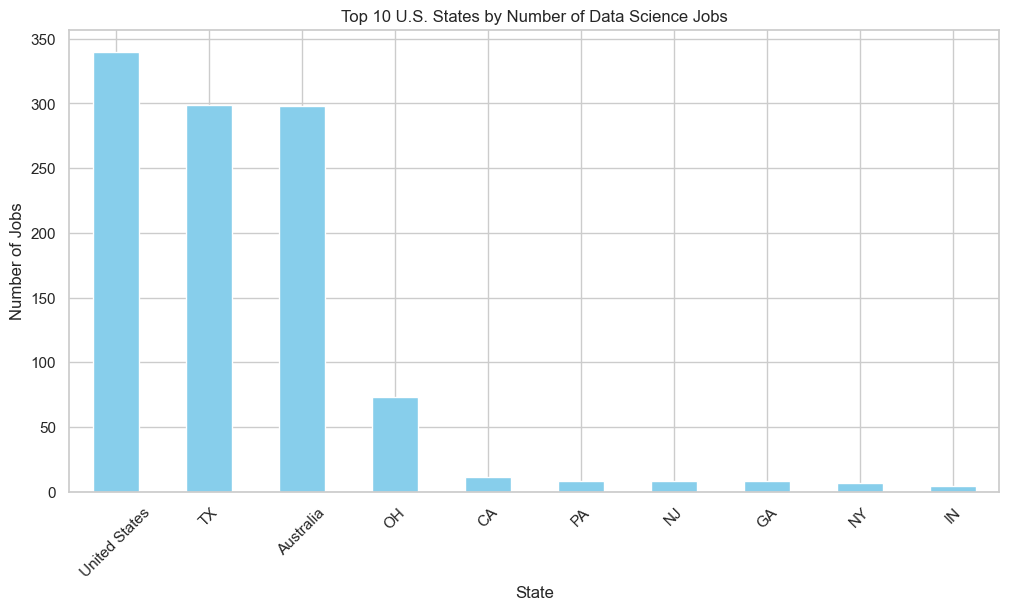


Top skills in United States:
skills_list
python                181
sql                   177
data analysis         130
project management    104
data visualization     94
Name: count, dtype: int64


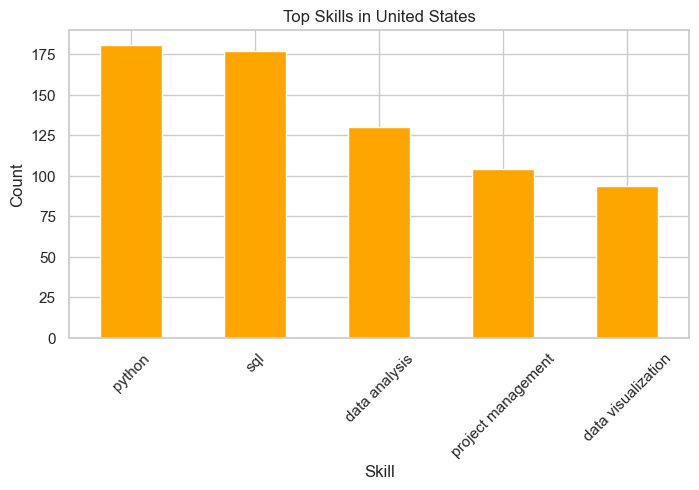


Top skills in TX:
skills_list
sql                   144
python                122
data visualization     80
data analysis          77
machine learning       71
Name: count, dtype: int64


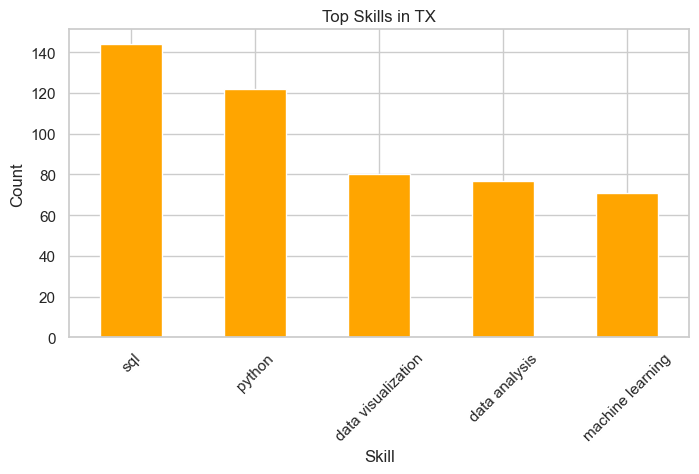


Top skills in Australia:
skills_list
sql                 124
python              110
data analysis        82
data engineering     70
communication        67
Name: count, dtype: int64


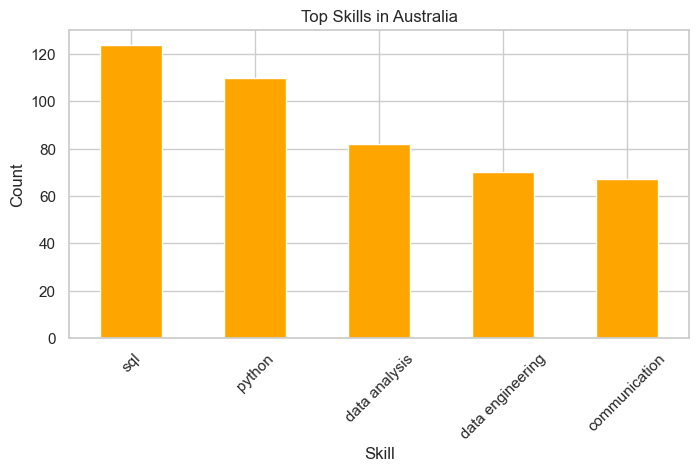


Top skills in OH:
skills_list
sql              21
python           18
communication    13
data analysis    13
data modeling    12
Name: count, dtype: int64


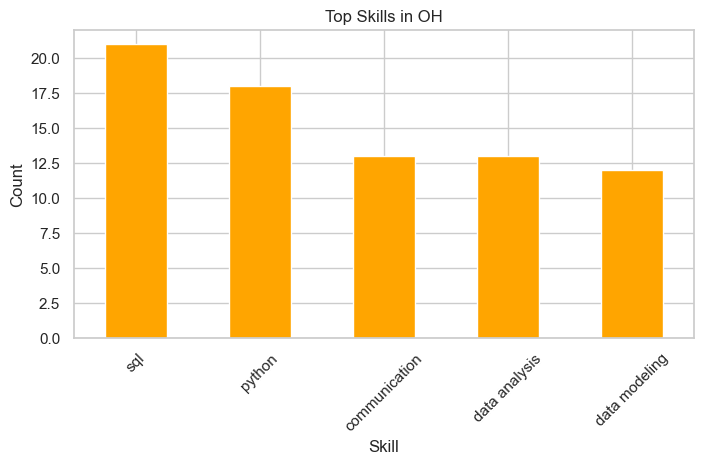


Top skills in CA:
skills_list
machine learning      7
python                6
sql                   5
r                     5
project management    4
Name: count, dtype: int64


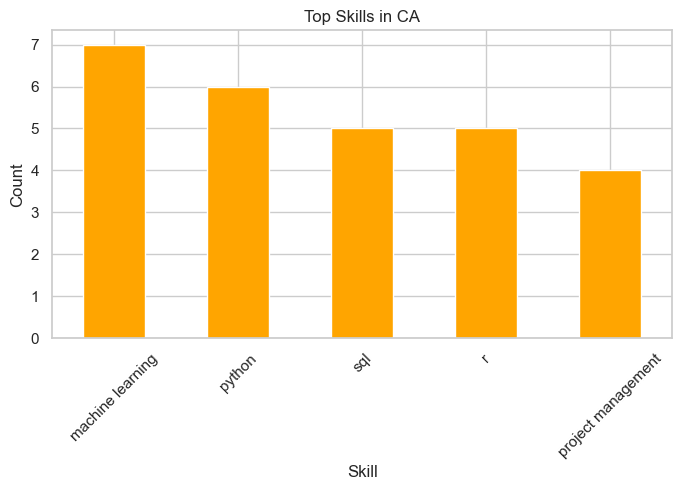


Jobs by work mode:
work_mode
onsite    1149
remote       9
hybrid       2
Name: count, dtype: int64


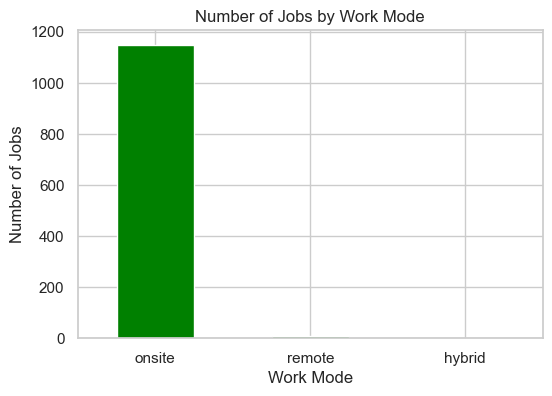


Top skills for onsite roles:
skills_list
sql                   530
python                500
data analysis         339
data visualization    273
communication         249
machine learning      247
data engineering      212
project management    211
r                     190
data modeling         174
Name: count, dtype: int64


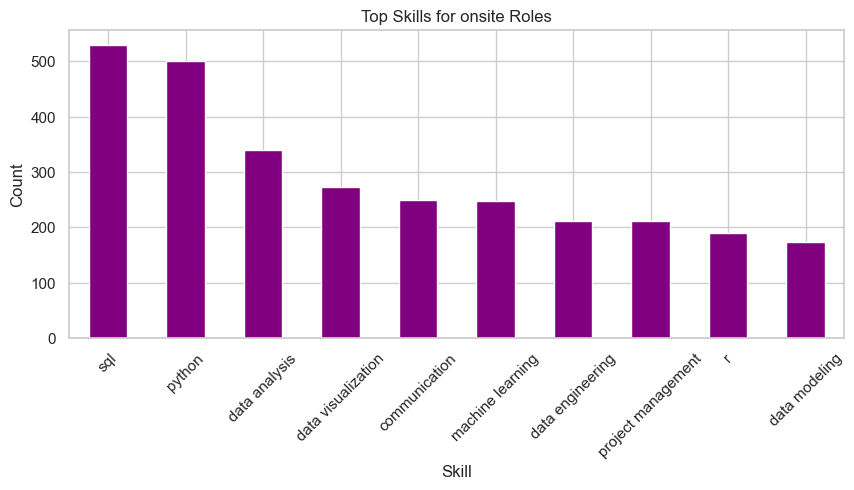


Top skills for remote roles:
skills_list
accuracy               7
medical terminology    7
attention to detail    7
data collection        6
remote work            6
data analysis          6
healthtech             6
data entry             5
software               5
saas                   5
Name: count, dtype: int64


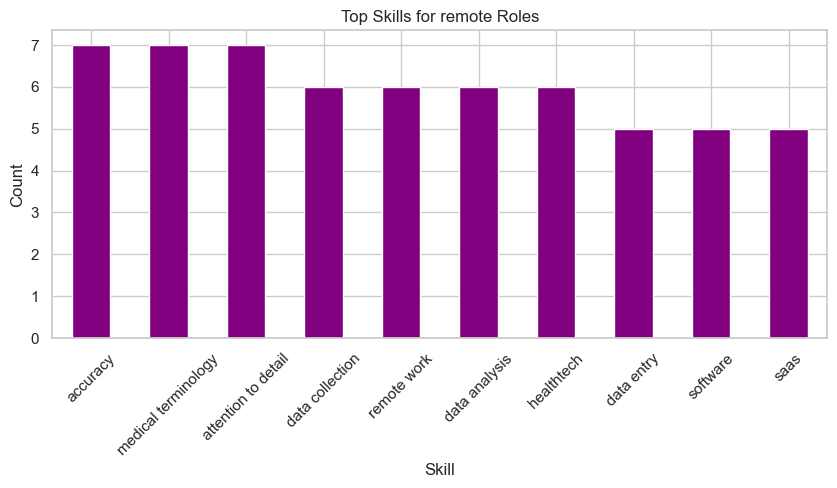


Top skills for hybrid roles:
skills_list
cloud consulting           1
data analytics             1
artificial intelligence    1
microsoft azure            1
amazon web services        1
sales                      1
business development       1
b2b sales                  1
consulting services        1
managed services           1
Name: count, dtype: int64


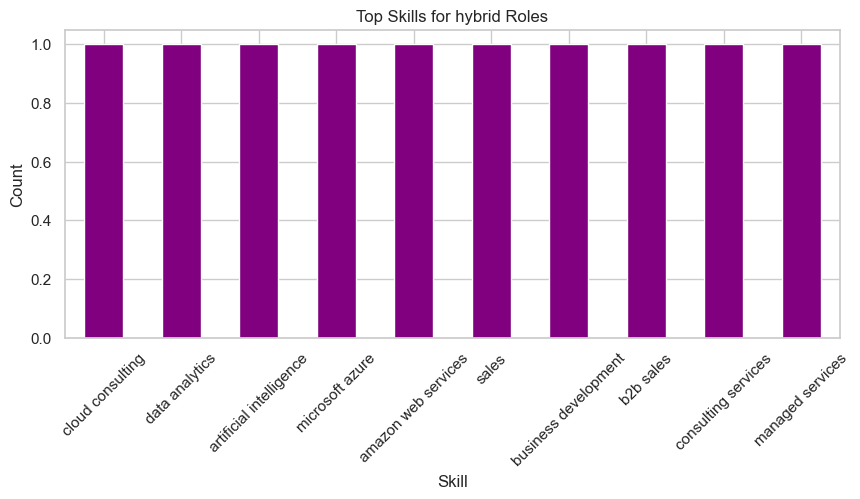


Data overview:
                                                 job_link  \
count                                                1160   
unique                                               1160   
top     https://au.linkedin.com/jobs/view/senior-data-...   
freq                                                    1   

                  last_processed_time   last_status got_summary got_ner  \
count                            1160          1160        1160    1160   
unique                            438             1           1       1   
top     2024-01-19 09:45:09.215838+00  Finished NER           t       t   
freq                              723          1160        1160    1160   

       is_being_worked                                          job_title  \
count             1160                                               1160   
unique               1                                                721   
top                  f  Contractor - Epic Clarity Data Analyst - Reven.

In [23]:
# -------------------------------
# Step 7: Pandas-based EDA & Visualizations
# -------------------------------

# 1️⃣ Jobs per state
jobs_per_state = df_us['state'].value_counts()
print("\nJobs per state:")
print(jobs_per_state.head(10))

plt.figure(figsize=(12,6))
jobs_per_state.head(10).plot(kind='bar', color='skyblue')
plt.title("Top 10 U.S. States by Number of Data Science Jobs")
plt.xlabel("State")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.show()

# 2️⃣ Top skills per state (top 5 skills for each of top 5 states)
top_states = jobs_per_state.head(5).index.tolist()
for state in top_states:
    skills_count = df_skills_exploded[df_skills_exploded['state']==state]['skills_list'].value_counts().head(5)
    print(f"\nTop skills in {state}:")
    print(skills_count)
    
    skills_count.plot(kind='bar', figsize=(8,4), title=f"Top Skills in {state}", color='orange')
    plt.xlabel("Skill")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

# 3️⃣ Jobs by work mode
jobs_by_mode = df_us['work_mode'].value_counts()
print("\nJobs by work mode:")
print(jobs_by_mode)

plt.figure(figsize=(6,4))
jobs_by_mode.plot(kind='bar', color='green')
plt.title("Number of Jobs by Work Mode")
plt.xlabel("Work Mode")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=0)
plt.show()

# 4️⃣ Top skills by work mode
for mode in df_us['work_mode'].unique():
    skills_count = df_skills_exploded[df_skills_exploded['work_mode']==mode]['skills_list'].value_counts().head(10)
    print(f"\nTop skills for {mode} roles:")
    print(skills_count)
    
    skills_count.plot(kind='bar', figsize=(10,4), title=f"Top Skills for {mode} Roles", color='purple')
    plt.xlabel("Skill")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

# 5️⃣ Quick summary stats
print("\nData overview:")
print(df_us.describe(include='all'))

print("\nMissing values per column:")
print(df_us.isna().sum())